In [1]:
!pip install qutip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 34.0 MB/s eta 0:00:00


In [2]:
#define physical parameters
import numpy as np
omega_p=0.5
omega_c=5
gamma_12=0.001
gamma_31=0.5
gamma_32=0.5
delta_c=0
delta_p=np.linspace(-10,10,400)

In [3]:
#define states
import qutip
from qutip import *
g1=basis(3,0)
g2=basis(3,1)
e=basis(3,2)




In [4]:
#define observables and operators
sigma_13=g1*e.dag() #takes 3 to 1
sigma_31=e*g1.dag() #takes 1 to 3
sigma_23=g2*e.dag() #takes 3 to 2
sigma_32=e*g2.dag() #takes 2 to 3
#population operators
p1=g1*g1.dag()
p2=g2*g2.dag()
p3=e*e.dag()



In [5]:

rho0=ket2dm(g1)
#collapse operators
import numpy as np
c1=np.sqrt(gamma_31)*g1*e.dag()
c2=np.sqrt(gamma_32)*g2*e.dag()
c3=np.sqrt(gamma_12)*(g1*g1.dag()-g2*g2.dag())
c_ops=[c1,c2,c3]

In [6]:
#time_evolution
absorption=[]
chi_real=[]
chi_imag=[]
n_real=[]
n_imag=[]
for del_p in delta_p:
  H=(-del_p*p3 -(del_p-delta_c)*p2    #hamiltonian
   +(omega_p/2)*(sigma_31+sigma_13)
   +(omega_c/2)*(sigma_32+sigma_23))

  rho_ss=steadystate(H,c_ops)
  absorption.append(-np.imag(rho_ss[2,0]))
  #get parameters like polarization,susceptibility,refractive index,group velocity
  gamma=1.0
  rho31=rho_ss[2,0]
  #susceptibility
  chi=rho31/omega_p
  chi_real.append(np.real(chi))
  chi_imag.append(np.imag(chi))
  #refractive index
  n=np.sqrt(1+chi)
  n_real.append(np.real(n))
  n_imag.append(np.imag(n))


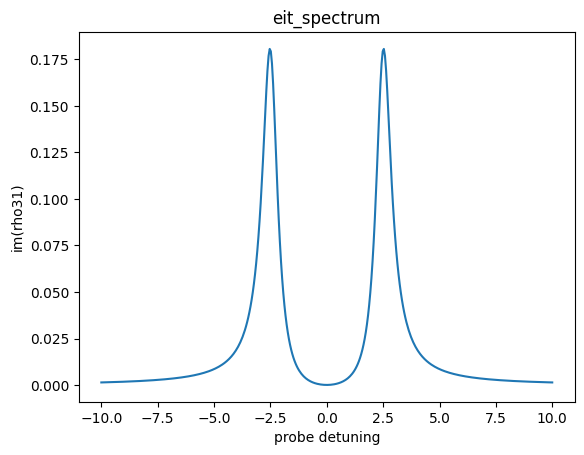

In [7]:
#plotting
import matplotlib.pyplot as plt
plt.plot(delta_p,absorption)
plt.xlabel("probe detuning")
plt.ylabel("im(rho31)")
plt.title("eit_spectrum")
plt.show()

In [8]:
for i in range(10):
  print(
      delta_p[i],
     chi_real[i],
      chi_imag[i],
      n_real[i],
      n_imag[i],
      absorption[i]
  )

-10.0 -0.052987024120625545 -0.002831394198614496 0.9731470044198377 -0.00145476181180997 0.001415697099307248
-9.949874686716791 -0.05328582754397677 -0.002863661500401945 0.9729934932888818 -0.001471572790647493 0.0014318307502009726
-9.899749373433584 -0.05358817743694301 -0.002896502164625731 0.9728381359459575 -0.00148868658495242 0.0014482510823128655
-9.849624060150376 -0.053894139508931 -0.002929930233030566 0.972680897756575 -0.0015061107089633708 0.001464965116515283
-9.799498746867169 -0.054203781140777924 -0.0029639601892352705 0.9725217431949441 -0.0015238529163872578 0.0014819800946176353
-9.74937343358396 -0.05451717143899721 -0.0029986069758015845 0.9723606358147269 -0.0015419212097624124 0.0014993034879007923
-9.699248120300751 -0.05483438129216611 -0.003033886012086038 0.9721975382186233 -0.0015603238502563414 0.001516943006043019
-9.649122807017545 -0.05515548342955609 -0.00306981321291755 0.9720324120267352 -0.0015790693679220218 0.001534906606458775
-9.598997493734

In [9]:
def probe_coeff(t,args): #define probe field
  Omega_p=args["Omega_p"]
  t0=4
  sigma=2
  return Omega_p*np.exp(-(t-t0)**2/(2*sigma**2))



In [10]:
def control_coeff(t,args):  #define control field
  Omega0=args["Omega0"]
  t_store=4
  t_retrieve=10
  tau=0.3
  off_switch=(1-np.tanh((t-t_store)/tau))/2

  on_switch=(1+np.tanh((t-t_retrieve)/tau))/2
  return Omega0*(off_switch+on_switch)

In [11]:
#hamiltonian in rotating frame
Delta=0.0
H0=Delta*(e*e.dag())
H=[
    H0,
    [-(sigma_13+sigma_31)/2,probe_coeff],
    [-(sigma_23+sigma_32)/2,control_coeff]
]

In [12]:
args={                          #define all the parameters
  "Omega_p":0.02,
  "Omega0":5
}

times=np.linspace(0,20,2000)
rho0=g1*g1.dag()
sigma_12=g1*g2.dag()
sigma_21=sigma_12.dag()


In [13]:
result=mesolve(
    H,
    rho0,
    times,
    c_ops,
    e_ops=[sigma_12,sigma_13,e*e.dag()],
    args=args
)

/usr/local/lib/python3.12/dist-packages/qutip/core/coefficient.py:199: FutureWarning: The signature f(t, args) is deprecated and will be removed in QuTiP 5.5. Please update your function to the pythonic signature f(t, **kwargs) to maintain compatibility.
  op = FunctionCoefficient(base, args.copy(), style=function_style)


In [14]:
spinwave=np.abs(result.expect[0])
optical=np.abs(result.expect[1])
excited=np.real(result.expect[2])

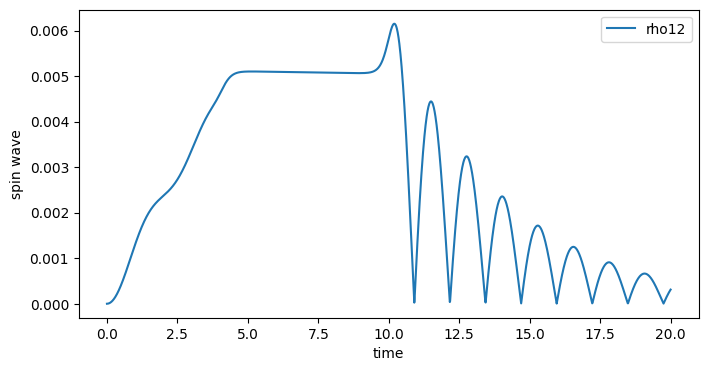

In [15]:
plt.figure(figsize=(8,4))
plt.plot(times,spinwave,label="rho12")
plt.xlabel("time")
plt.ylabel("spin wave")
plt.legend()
plt.show()


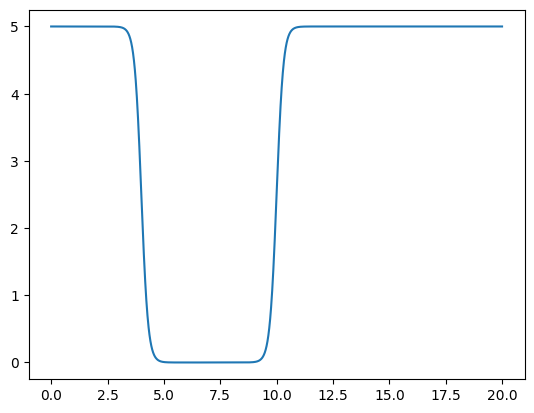

In [16]:
control=[control_coeff(t,args) for t in times]
plt.plot(times,control)

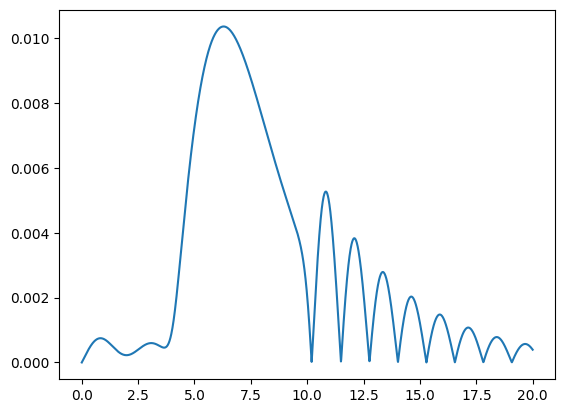

In [17]:
plt.plot(times,np.abs(result.expect[1]))
plt.show()

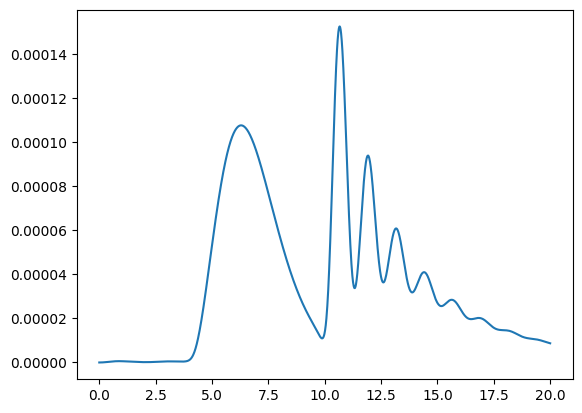

In [18]:
plt.plot(times,np.abs(result.expect[2]))
plt.show()